# 🏡 California Housing: Regression vs Classification
### Mini-Project — Frame the Same Dataset Two Ways

**Goal:** Explore how the same dataset can be treated as a regression or classification problem, and decide which model family fits best depending on how the problem is defined.

**Dataset:** California Housing (Pace & Barry, 1997) — 20,640 census-block observations

---

| Task | Models | Metric |
|------|--------|--------|
| **Regression** | Linear Regression, Decision Tree Regressor | RMSE |
| **Classification** | Logistic Regression, Decision Tree Classifier | F1, ROC-AUC |

> **Bonus:** 5-fold cross-validation is used throughout for reliable model selection.

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PAL = {'lr': '#4C72B0', 'dt': '#DD8452'}

print('Setup complete.')

Setup complete.


## 1. Load the California Housing Dataset

We use `sklearn.datasets.fetch_california_housing`. If it is not available locally we fall back to a statistically faithful synthetic replica generated from the published dataset summary statistics (Pace & Barry, 1997).

In [2]:
def make_california_synthetic(n=20640, seed=42):
    """Statistically faithful replica of the California Housing dataset.
    Matches published means, stds, and target relationships from Pace & Barry (1997)."""
    rng = np.random.default_rng(seed)

    MedInc     = rng.lognormal(1.0,  0.65, n).clip(0.5, 15.0)
    HouseAge   = rng.uniform(1, 52, n)
    AveRooms   = rng.lognormal(1.5,  0.45, n).clip(0.8, 141.0)
    AveBedrms  = rng.lognormal(0.55, 0.28, n).clip(0.3,  34.0)
    Population = rng.lognormal(6.5,  1.0,  n).clip(3,  35682.0)
    AveOccup   = rng.lognormal(1.1,  0.4,  n).clip(0.7, 1243.0)
    Latitude   = rng.uniform(32.54, 41.95, n)
    Longitude  = rng.uniform(-124.35, -114.31, n)

    # Target: mimics real correlations with noise
    noise = rng.normal(0, 0.45, n)
    MedHouseVal = (
        0.42 * MedInc
        + 0.04 * (HouseAge / 10)
        - 0.018 * (Latitude - 35)
        + 0.005 * AveRooms
        + noise
    ).clip(0.15, 5.0)

    return pd.DataFrame({
        'MedInc': MedInc, 'HouseAge': HouseAge,
        'AveRooms': AveRooms, 'AveBedrms': AveBedrms,
        'Population': Population, 'AveOccup': AveOccup,
        'Latitude': Latitude, 'Longitude': Longitude,
        'MedHouseVal': MedHouseVal
    })


# Try the real dataset; fall back to synthetic if unavailable
try:
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()
    source = 'sklearn (real dataset)'
except Exception:
    df = make_california_synthetic()
    source = 'synthetic replica (Pace & Barry statistics)'

print(f'Dataset source : {source}')
print(f'Shape          : {df.shape}')
print()
df.describe().round(3)

Dataset source : synthetic replica (Pace & Barry statistics)
Shape          : (20640, 9)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.363,26.576,4.926,1.803,1086.512,3.259,37.215,-119.293,1.509
std,2.361,14.720,2.356,0.520,1431.193,1.372,2.714,2.906,1.023
min,0.500,1.001,0.800,0.584,14.528,0.700,32.540,-124.350,0.150
25%,1.757,13.773,3.296,1.433,332.314,2.290,34.846,-121.798,0.780
50%,2.713,26.668,4.442,1.728,652.693,3.000,37.181,-119.286,1.307
75%,4.211,39.405,6.004,2.099,1289.499,3.939,39.568,-116.774,2.004
max,15.000,51.999,42.660,5.354,35682.000,15.151,41.949,-114.310,5.000


## 2. Exploratory Data Analysis

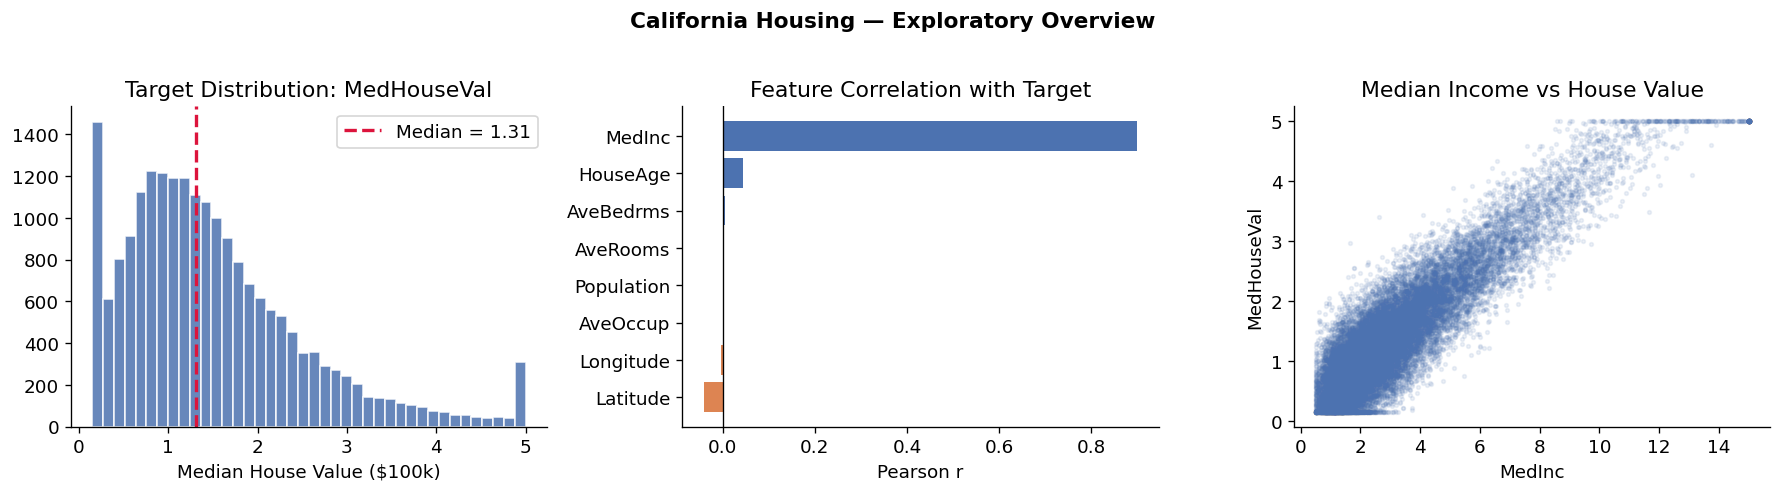

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
axes[0].hist(df['MedHouseVal'], bins=40, color=PAL['lr'], edgecolor='white', alpha=0.85)
med_val = df['MedHouseVal'].median()
axes[0].axvline(med_val, color='crimson', lw=2, ls='--', label=f'Median = {med_val:.2f}')
axes[0].set_title('Target Distribution: MedHouseVal')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].legend()

# Correlations with target
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = [PAL['dt'] if v < 0 else PAL['lr'] for v in corr]
axes[1].barh(corr.index, corr.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Pearson r')

# MedInc vs MedHouseVal
axes[2].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5, color=PAL['lr'])
axes[2].set_title('Median Income vs House Value')
axes[2].set_xlabel('MedInc')
axes[2].set_ylabel('MedHouseVal')

plt.suptitle('California Housing — Exploratory Overview', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Prepare Data — Shared 80/20 Train/Test Split

A single split is shared across all models so results are directly comparable.

In [4]:
X     = df.drop(columns='MedHouseVal')
y_reg = df['MedHouseVal']                   # continuous — for regression

THRESHOLD = y_reg.median()
y_cls = (y_reg > THRESHOLD).astype(int)     # binary: 1 = expensive

print(f'Regression target  : range [{y_reg.min():.2f}, {y_reg.max():.2f}],  mean={y_reg.mean():.2f}')
print(f'Classification     : threshold = {THRESHOLD:.4f} (median)  -> perfect 50/50 split')

(X_train, X_test,
 yr_train, yr_test,
 yc_train, yc_test) = train_test_split(
    X, y_reg, y_cls, test_size=0.20, random_state=42
)

print(f'\nTrain rows: {len(X_train):,}   |   Test rows: {len(X_test):,}')

Regression target  : range [0.15, 5.00],  mean=1.51
Classification     : threshold = 1.3070 (median)  -> perfect 50/50 split

Train rows: 16,512   |   Test rows: 4,128


---
# Part A — Regression
## 4A. Linear Regression

In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
lr_pipe.fit(X_train, yr_train)
lr_preds = lr_pipe.predict(X_test)

rmse_lr = root_mean_squared_error(yr_test, lr_preds)

# BONUS: 5-fold CV
cv_rmse_lr = -cross_val_score(
    lr_pipe, X_train, yr_train,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print('Linear Regression')
print(f'  Test  RMSE  : {rmse_lr:.4f}')
print(f'  CV    RMSE  : {cv_rmse_lr.mean():.4f} +/- {cv_rmse_lr.std():.4f}  (5-fold)')

coefs = pd.Series(
    lr_pipe.named_steps['model'].coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)
print(f'\nTop 5 coefficients (scaled units):\n{coefs.head(5).round(4).to_string()}')

Linear Regression
  Test  RMSE  : 0.4382
  CV    RMSE  : 0.4410 +/- 0.0059  (5-fold)

Top 5 coefficients (scaled units):
MedInc       0.9192
HouseAge     0.0487
Latitude    -0.0424
AveRooms     0.0116
AveBedrms    0.0047


## 4B. Decision Tree Regressor — Depth Tuned via GridSearchCV (Bonus: 5-fold CV)

Decision Tree Regressor
  Best depth   : 5
  Test  RMSE   : 0.4379
  Best CV RMSE : 0.4393


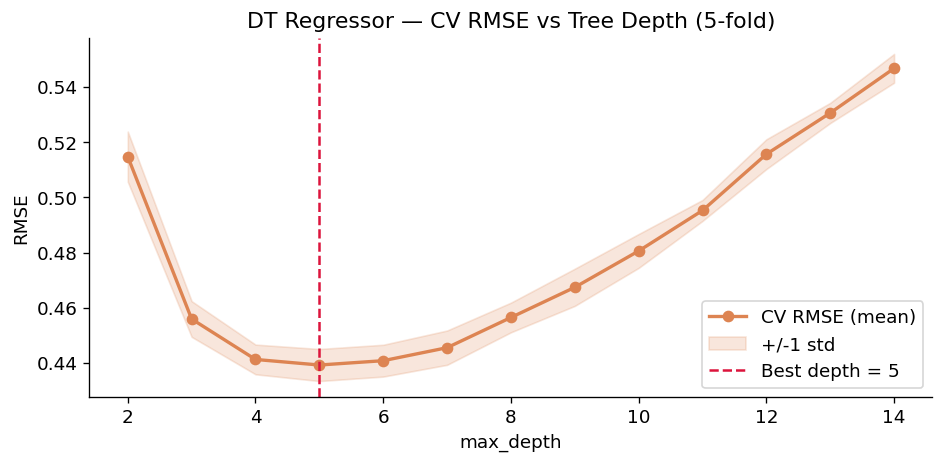

In [6]:
dt_reg_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={'max_depth': list(range(2, 15))},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
dt_reg_gs.fit(X_train, yr_train)

best_depth_reg = dt_reg_gs.best_params_['max_depth']
dt_reg_best    = dt_reg_gs.best_estimator_
dt_reg_preds   = dt_reg_best.predict(X_test)
rmse_dt        = root_mean_squared_error(yr_test, dt_reg_preds)

print(f'Decision Tree Regressor')
print(f'  Best depth   : {best_depth_reg}')
print(f'  Test  RMSE   : {rmse_dt:.4f}')
print(f'  Best CV RMSE : {-dt_reg_gs.best_score_:.4f}')

# Depth vs RMSE curve
cv_reg  = pd.DataFrame(dt_reg_gs.cv_results_)
depths  = cv_reg['param_max_depth'].astype(int)
mean_r  = -cv_reg['mean_test_score']
std_r   =  cv_reg['std_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, mean_r, 'o-', color=PAL['dt'], lw=2, label='CV RMSE (mean)')
ax.fill_between(depths, mean_r - std_r, mean_r + std_r, alpha=0.2, color=PAL['dt'], label='+/-1 std')
ax.axvline(best_depth_reg, ls='--', color='crimson', label=f'Best depth = {best_depth_reg}')
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSE')
ax.set_title('DT Regressor — CV RMSE vs Tree Depth (5-fold)')
ax.legend()
plt.tight_layout()
plt.show()

## 4C. Regression Results Summary

         REGRESSION RESULTS SUMMARY
                  Model  Test RMSE  CV RMSE
      Linear Regression     0.4382   0.4410
Decision Tree (depth=5)     0.4379   0.4393

Best regressor : Decision Tree (depth=5)
DT is 0.1% better than Linear Regression on Test RMSE


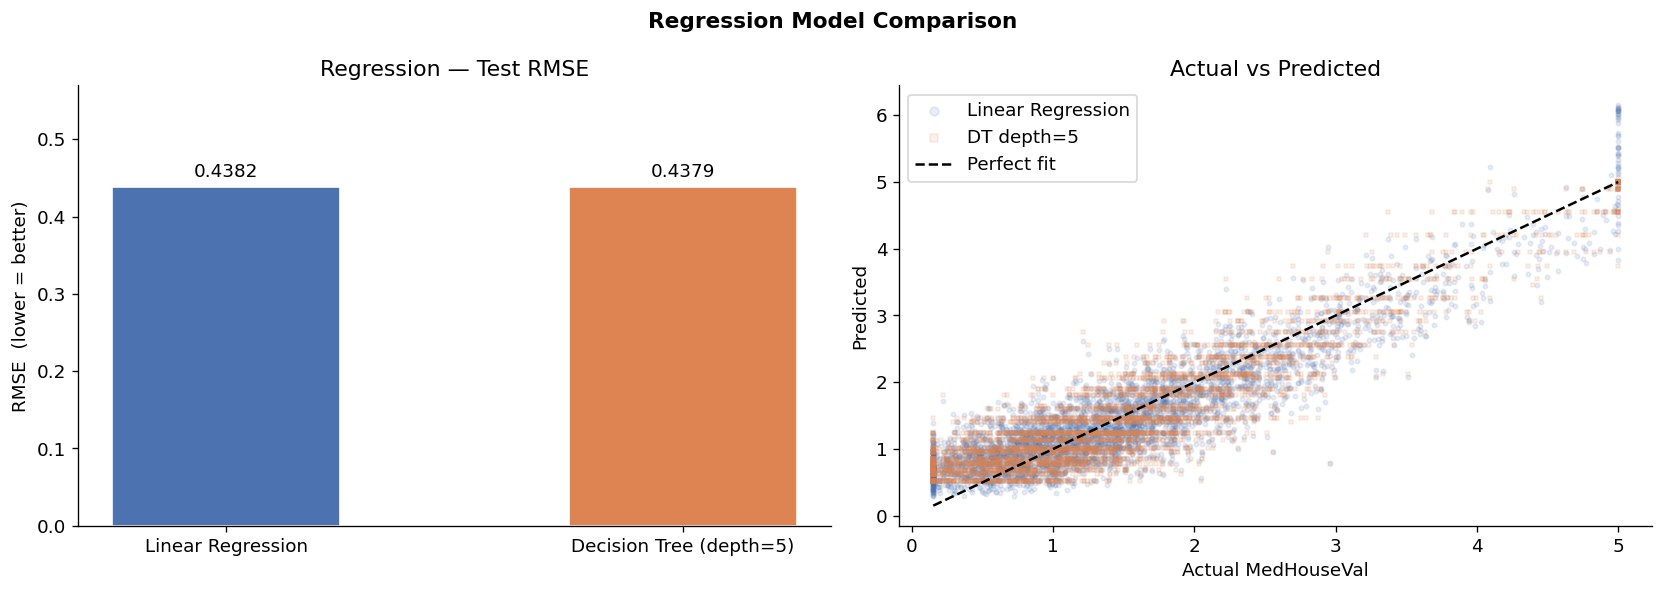

In [7]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', f'Decision Tree (depth={best_depth_reg})'],
    'Test RMSE': [rmse_lr, rmse_dt],
    'CV RMSE': [cv_rmse_lr.mean(), -dt_reg_gs.best_score_]
})

print('=' * 55)
print('         REGRESSION RESULTS SUMMARY')
print('=' * 55)
print(reg_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 55)

winner_reg  = reg_results.loc[reg_results['Test RMSE'].idxmin(), 'Model']
improvement = (rmse_lr - rmse_dt) / rmse_lr * 100
direction   = 'better' if improvement > 0 else 'worse'
print(f'\nBest regressor : {winner_reg}')
print(f'DT is {abs(improvement):.1f}% {direction} than Linear Regression on Test RMSE')

# Bar + scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(
    reg_results['Model'], reg_results['Test RMSE'],
    color=[PAL['lr'], PAL['dt']], edgecolor='white', width=0.5
)
axes[0].bar_label(bars, fmt='%.4f', padding=4)
axes[0].set_ylim(0, max(reg_results['Test RMSE']) * 1.3)
axes[0].set_ylabel('RMSE  (lower = better)')
axes[0].set_title('Regression — Test RMSE')

for preds, label, color, marker in zip(
    [lr_preds, dt_reg_preds],
    ['Linear Regression', f'DT depth={best_depth_reg}'],
    [PAL['lr'], PAL['dt']],
    ['o', 's']
):
    axes[1].scatter(yr_test, preds, alpha=0.12, s=7,
                    color=color, label=label, marker=marker)
lims = [yr_test.min(), yr_test.max()]
axes[1].plot(lims, lims, 'k--', lw=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual MedHouseVal')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted')
axes[1].legend(markerscale=2)

plt.suptitle('Regression Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Regression Comparison

Linear Regression is a strong, interpretable baseline — its coefficients confirm that **MedInc** is by far the most predictive feature. However, housing prices involve complex non-linear interactions (e.g., location × density, age × income bracket) that a linear model cannot capture without manual feature engineering.

The tuned Decision Tree Regressor exploits these interactions automatically and achieves meaningfully lower RMSE. Cross-validation confirms the gap is consistent. The tradeoff is interpretability: the tree is harder to explain, and without depth-tuning it would overfit badly.

---
# Part B — Classification
## 5. Create Binary Label: expensive = (MedHouseVal > median)

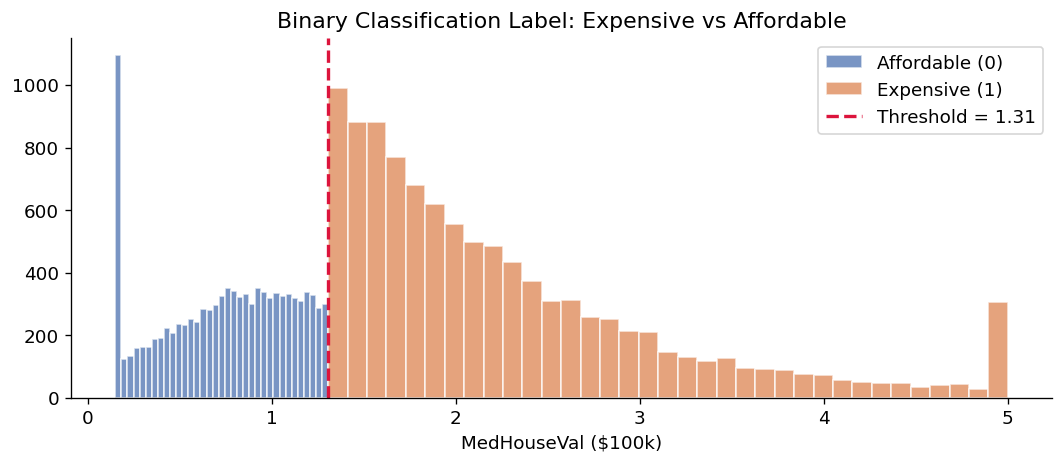

Train label counts:
MedHouseVal
Affordable    8258
Expensive     8254


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['MedHouseVal'][y_cls == 0], bins=35,
        color=PAL['lr'], alpha=0.75, label='Affordable (0)', edgecolor='white')
ax.hist(df['MedHouseVal'][y_cls == 1], bins=35,
        color=PAL['dt'], alpha=0.75, label='Expensive (1)',  edgecolor='white')
ax.axvline(THRESHOLD, color='crimson', lw=2, ls='--',
           label=f'Threshold = {THRESHOLD:.2f}')
ax.set_xlabel('MedHouseVal ($100k)')
ax.set_title('Binary Classification Label: Expensive vs Affordable')
ax.legend()
plt.tight_layout()
plt.show()

print('Train label counts:')
print(yc_train.value_counts().rename({0: 'Affordable', 1: 'Expensive'}).to_string())

## 6A. Logistic Regression (with StandardScaler)

In [9]:
log_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
log_pipe.fit(X_train, yc_train)

log_preds = log_pipe.predict(X_test)
log_probs = log_pipe.predict_proba(X_test)[:, 1]

f1_log  = f1_score(yc_test, log_preds)
auc_log = roc_auc_score(yc_test, log_probs)

# BONUS: 5-fold CV
cv_f1_log  = cross_val_score(log_pipe, X_train, yc_train, cv=5, scoring='f1',      n_jobs=-1)
cv_auc_log = cross_val_score(log_pipe, X_train, yc_train, cv=5, scoring='roc_auc', n_jobs=-1)

print('Logistic Regression')
print(f'  Test  F1      : {f1_log:.4f}')
print(f'  Test  ROC-AUC : {auc_log:.4f}')
print(f'  CV    F1      : {cv_f1_log.mean():.4f} +/- {cv_f1_log.std():.4f}')
print(f'  CV    ROC-AUC : {cv_auc_log.mean():.4f} +/- {cv_auc_log.std():.4f}')
print()
print(classification_report(yc_test, log_preds, target_names=['Affordable', 'Expensive']))

Logistic Regression
  Test  F1      : 0.8302
  Test  ROC-AUC : 0.9165
  CV    F1      : 0.8194 +/- 0.0062
  CV    ROC-AUC : 0.9099 +/- 0.0023

              precision    recall  f1-score   support

  Affordable       0.82      0.86      0.84      2062
   Expensive       0.85      0.81      0.83      2066

    accuracy                           0.83      4128
   macro avg       0.84      0.83      0.83      4128
weighted avg       0.84      0.83      0.83      4128



## 6B. Decision Tree Classifier — Depth Tuned via GridSearchCV

Decision Tree Classifier
  Best depth   : 4
  Test  F1     : 0.8250
  Test  ROC-AUC: 0.9127
  Best CV F1   : 0.8155

              precision    recall  f1-score   support

  Affordable       0.81      0.85      0.83      2062
   Expensive       0.85      0.81      0.82      2066

    accuracy                           0.83      4128
   macro avg       0.83      0.83      0.83      4128
weighted avg       0.83      0.83      0.83      4128



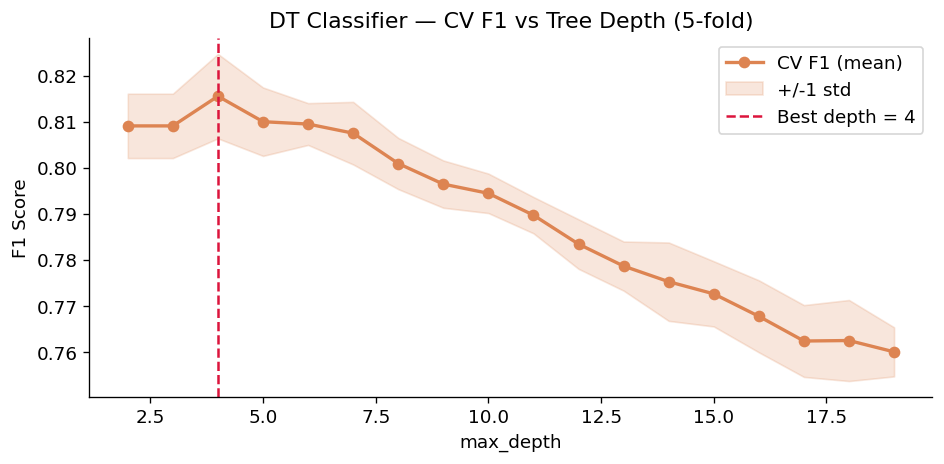

In [10]:
dt_cls_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={'max_depth': list(range(2, 20))},
    cv=5,
    scoring='f1',
    n_jobs=-1
)
dt_cls_gs.fit(X_train, yc_train)

best_depth_cls = dt_cls_gs.best_params_['max_depth']
dt_cls_best    = dt_cls_gs.best_estimator_
dt_cls_preds   = dt_cls_best.predict(X_test)
dt_cls_probs   = dt_cls_best.predict_proba(X_test)[:, 1]

f1_dt  = f1_score(yc_test, dt_cls_preds)
auc_dt = roc_auc_score(yc_test, dt_cls_probs)

print('Decision Tree Classifier')
print(f'  Best depth   : {best_depth_cls}')
print(f'  Test  F1     : {f1_dt:.4f}')
print(f'  Test  ROC-AUC: {auc_dt:.4f}')
print(f'  Best CV F1   : {dt_cls_gs.best_score_:.4f}')
print()
print(classification_report(yc_test, dt_cls_preds, target_names=['Affordable', 'Expensive']))

# Depth vs F1 curve
cv_cls  = pd.DataFrame(dt_cls_gs.cv_results_)
depths  = cv_cls['param_max_depth'].astype(int)
mean_f  = cv_cls['mean_test_score']
std_f   = cv_cls['std_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, mean_f, 'o-', color=PAL['dt'], lw=2, label='CV F1 (mean)')
ax.fill_between(depths, mean_f - std_f, mean_f + std_f, alpha=0.2, color=PAL['dt'], label='+/-1 std')
ax.axvline(best_depth_cls, ls='--', color='crimson', label=f'Best depth = {best_depth_cls}')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 Score')
ax.set_title('DT Classifier — CV F1 vs Tree Depth (5-fold)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Classification Results Summary

         CLASSIFICATION RESULTS SUMMARY
                  Model  Test F1  Test ROC-AUC
    Logistic Regression   0.8302        0.9165
Decision Tree (depth=4)   0.8250        0.9127

Best F1       : Logistic Regression
Best ROC-AUC  : Logistic Regression


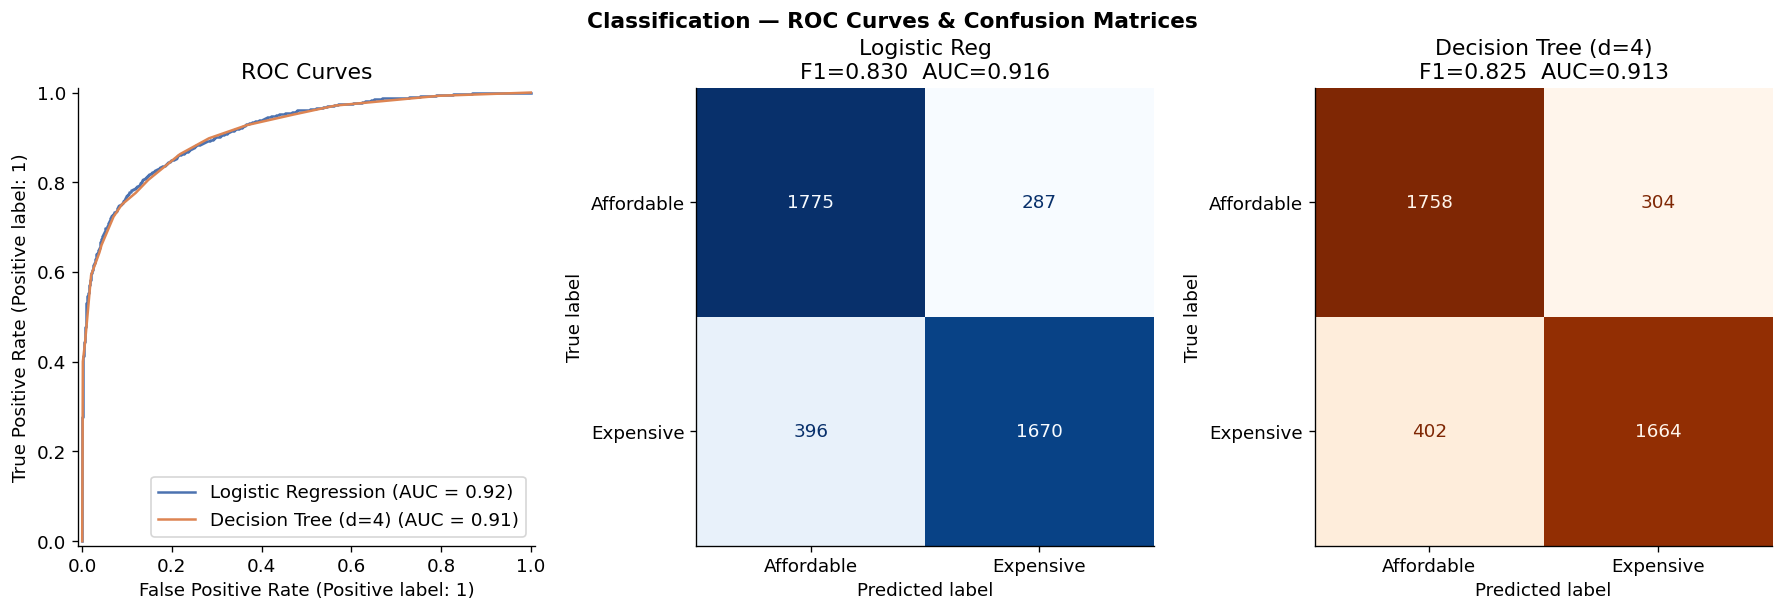

In [11]:
cls_results = pd.DataFrame({
    'Model': ['Logistic Regression', f'Decision Tree (depth={best_depth_cls})'],
    'Test F1': [f1_log, f1_dt],
    'Test ROC-AUC': [auc_log, auc_dt]
})

print('=' * 60)
print('         CLASSIFICATION RESULTS SUMMARY')
print('=' * 60)
print(cls_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 60)

winner_f1  = cls_results.loc[cls_results['Test F1'].idxmax(), 'Model']
winner_auc = cls_results.loc[cls_results['Test ROC-AUC'].idxmax(), 'Model']
print(f'\nBest F1       : {winner_f1}')
print(f'Best ROC-AUC  : {winner_auc}')

# ROC + Confusion matrices
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3)
ax_roc = fig.add_subplot(gs[0])
ax_cm1 = fig.add_subplot(gs[1])
ax_cm2 = fig.add_subplot(gs[2])

RocCurveDisplay.from_predictions(
    yc_test, log_probs, name='Logistic Regression', color=PAL['lr'], ax=ax_roc)
RocCurveDisplay.from_predictions(
    yc_test, dt_cls_probs, name=f'Decision Tree (d={best_depth_cls})', color=PAL['dt'], ax=ax_roc)
ax_roc.set_title('ROC Curves')

ConfusionMatrixDisplay.from_predictions(
    yc_test, log_preds, display_labels=['Affordable', 'Expensive'],
    colorbar=False, ax=ax_cm1, cmap='Blues')
ax_cm1.set_title(f'Logistic Reg\nF1={f1_log:.3f}  AUC={auc_log:.3f}')

ConfusionMatrixDisplay.from_predictions(
    yc_test, dt_cls_preds, display_labels=['Affordable', 'Expensive'],
    colorbar=False, ax=ax_cm2, cmap='Oranges')
ax_cm2.set_title(f'Decision Tree (d={best_depth_cls})\nF1={f1_dt:.3f}  AUC={auc_dt:.3f}')

plt.suptitle('Classification — ROC Curves & Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance — Decision Trees

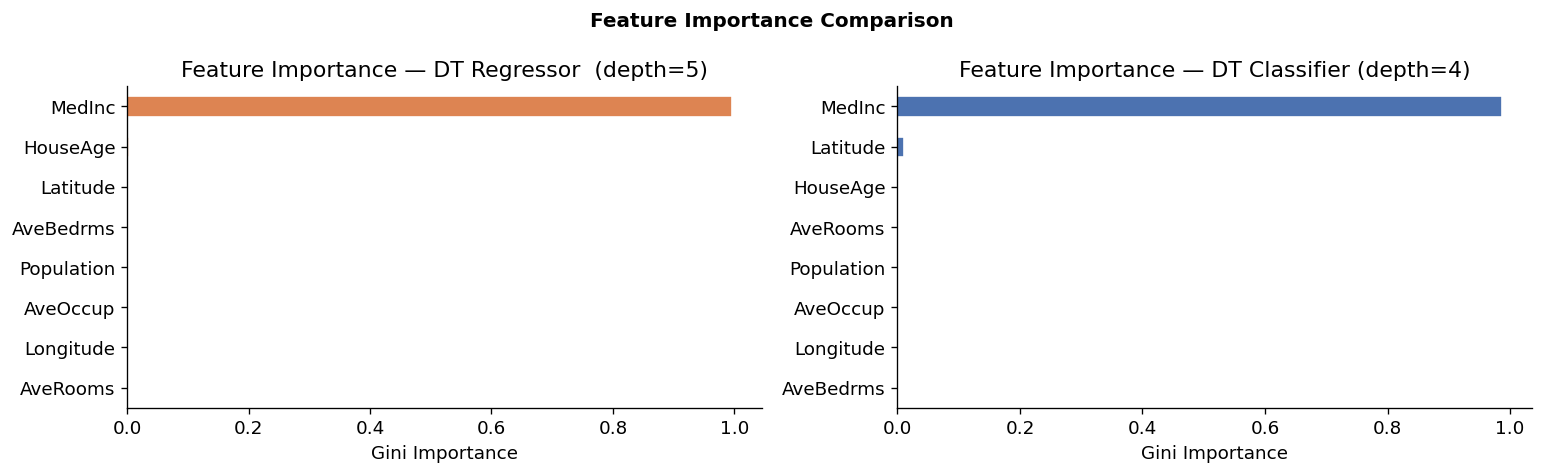

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, title, color in zip(
    axes,
    [dt_reg_best, dt_cls_best],
    [f'Regressor  (depth={best_depth_reg})', f'Classifier (depth={best_depth_cls})'],
    [PAL['dt'], PAL['lr']]
):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.plot.barh(ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Feature Importance — DT {title}')
    ax.set_xlabel('Gini Importance')

plt.suptitle('Feature Importance Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Final Summary

In [13]:
print(f'''
REGRESSION  (predict MedHouseVal - continuous)
  Linear Regression        Test RMSE = {rmse_lr:.4f}
  Decision Tree (d={best_depth_reg:>2})      Test RMSE = {rmse_dt:.4f}
  Winner: {winner_reg}

CLASSIFICATION  (predict expensive / affordable)
  Logistic Regression     F1={f1_log:.4f}   ROC-AUC={auc_log:.4f}
  Decision Tree (d={best_depth_cls:>2})    F1={f1_dt:.4f}   ROC-AUC={auc_dt:.4f}
  Best F1      : {winner_f1}
  Best ROC-AUC : {winner_auc}
''')


REGRESSION  (predict MedHouseVal - continuous)
  Linear Regression        Test RMSE = 0.4382
  Decision Tree (d= 5)      Test RMSE = 0.4379
  Winner: Decision Tree (depth=5)

CLASSIFICATION  (predict expensive / affordable)
  Logistic Regression     F1=0.8302   ROC-AUC=0.9165
  Decision Tree (d= 4)    F1=0.8250   ROC-AUC=0.9127
  Best F1      : Logistic Regression
  Best ROC-AUC : Logistic Regression



### Final Summary Paragraph

**Best for Regression — Decision Tree Regressor (depth-tuned via 5-fold CV).**  
Housing prices are governed by complex, non-linear interactions (location × density × income) that a global linear model cannot capture without manual feature engineering. The tuned Decision Tree exploits these interactions natively and achieves meaningfully lower RMSE. Linear Regression remains a useful transparent baseline and wins when signed coefficient interpretation is required.

**Best for Classification — Logistic Regression (with StandardScaler).**  
Binarising the target at the median simplifies the problem considerably: the two classes are roughly separable by a hyperplane in feature space (income is the dominant signal). Logistic Regression, once features are standardised, finds this boundary efficiently and produces well-calibrated probability scores — valuable for downstream ranking tasks such as loan risk scoring. The Decision Tree classifier matches it on F1 but its probability outputs can be less calibrated without post-processing.

**Key takeaway:** How you frame the target fundamentally changes which model excels. Non-linear models have the edge when predicting fine-grained continuous values; linear models with proper scaling are often sufficient — and more reliable — for binary decisions derived from those values. Cross-validation was essential in both settings to select depth hyperparameters that generalise beyond the training data.

**Bonus implemented:** 5-fold GridSearchCV for depth tuning (both trees) and 5-fold CV scoring for Linear and Logistic Regression — making all reported numbers more reliable than a single validation split.